ACF/PACF diagnostic plots saved.

Running Unsupervised Change-Point Detection (PELT)...
Algorithm detected 3 major regime breaks at:
2016-07-20
2023-06-16
2024-02-02
Structural break visualization saved.


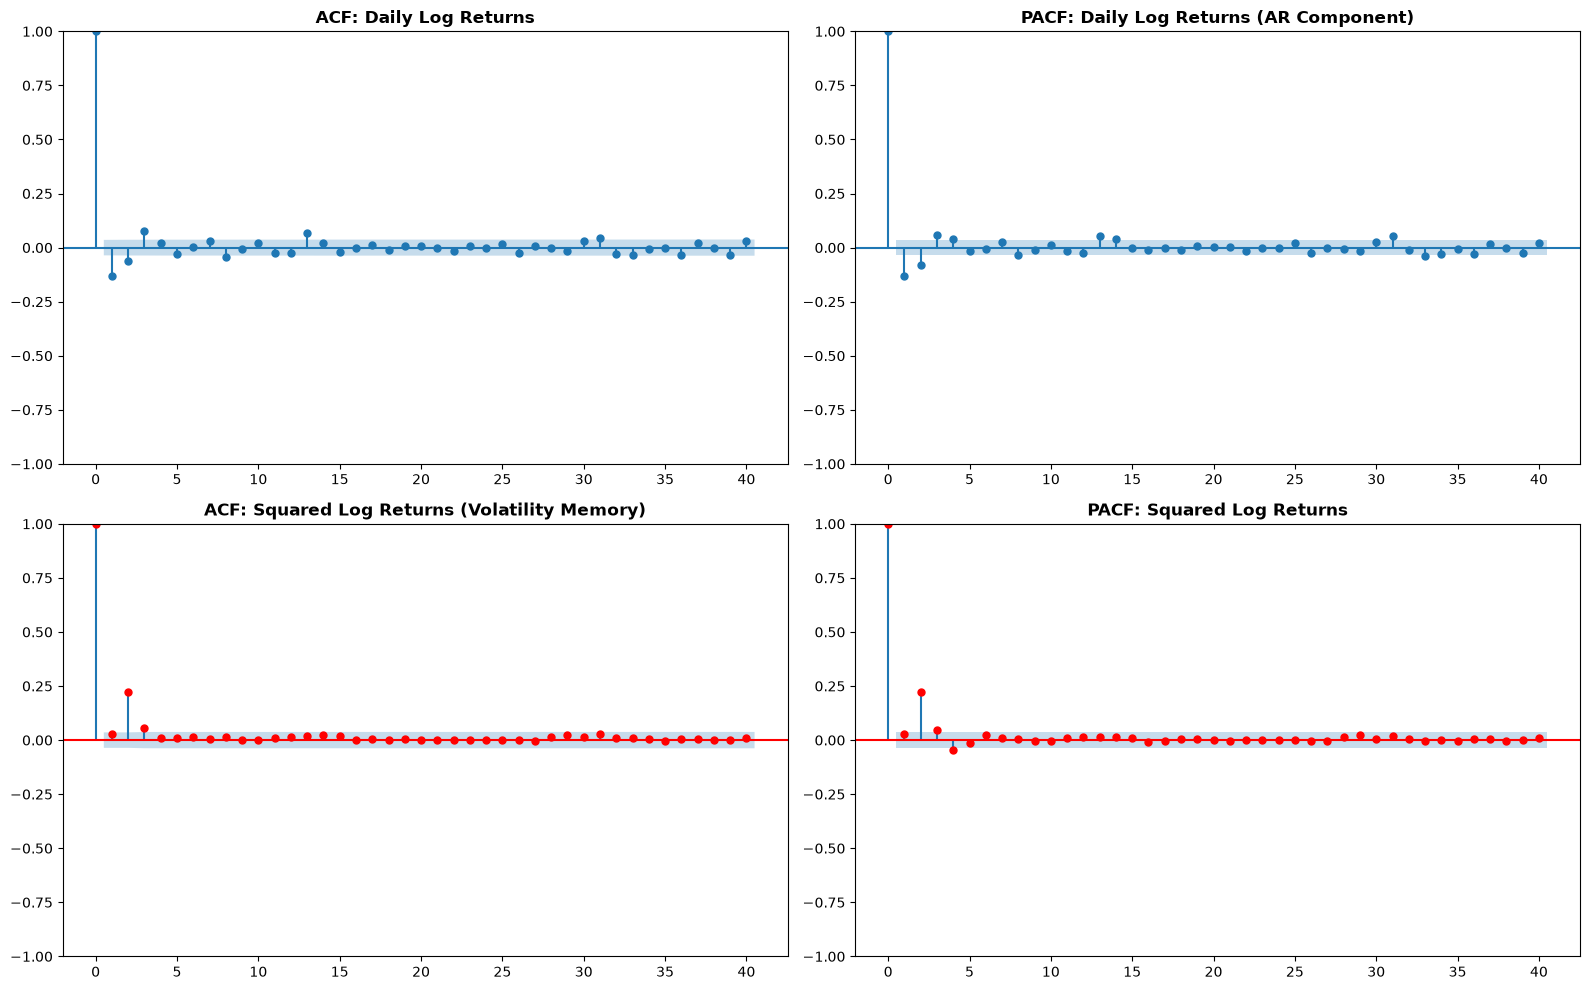

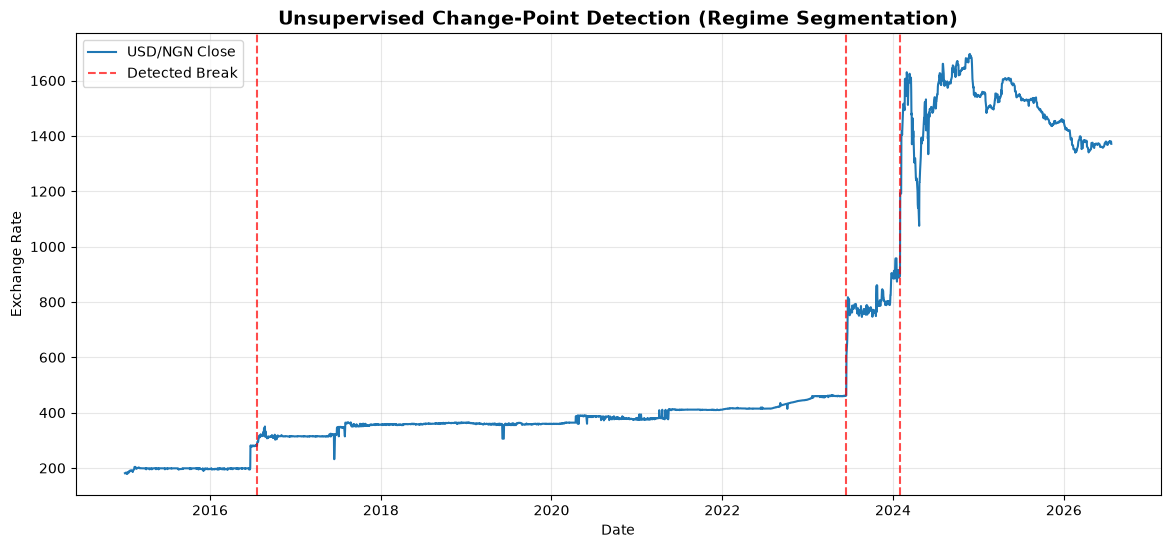

Loading structural breaks from cache...


In [27]:
import pandas as pd
import numpy as np
import json
import os
import ruptures as rpt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


def load_clean_data(filepath="../data/raw/raw_usd_ngn.csv"):
    df = pd.read_csv(filepath, parse_dates=["Date"], index_col="Date")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    # Apply our data engineering fix from earlier
    df = df[df["Close"] > 100]
    df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))
    return df.dropna()


def generate_autocorrelation_plots(df):
    """Generates diagnostic ACF/PACF plots for the Medium article."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Log Returns ACF/PACF (Checking for mean dependency)
    plot_acf(df["Log_Returns"], ax=axes[0, 0], lags=40, alpha=0.05)
    axes[0, 0].set_title("ACF: Daily Log Returns", fontweight="bold")

    plot_pacf(df["Log_Returns"], ax=axes[0, 1], lags=40, alpha=0.05)
    axes[0, 1].set_title(
        "PACF: Daily Log Returns (AR Component)", fontweight="bold"
    )

    # 2. Squared Log Returns ACF/PACF (Proving Volatility Clustering)
    squared_returns = df["Log_Returns"] ** 2
    plot_acf(squared_returns, ax=axes[1, 0], lags=40, alpha=0.05, color="red")
    axes[1, 0].set_title(
        "ACF: Squared Log Returns (Volatility Memory)", fontweight="bold"
    )

    plot_pacf(squared_returns, ax=axes[1, 1], lags=40, alpha=0.05, color="red")
    axes[1, 1].set_title("PACF: Squared Log Returns", fontweight="bold")

    plt.tight_layout()
    plt.savefig("../reports/figures/usd_ngn_acf_pacf.png", dpi=300)
    print("ACF/PACF diagnostic plots saved.")


def detect_structural_breaks(df):
    """Uses the Pruned Exact Linear Time (PELT) algorithm to find regime shifts."""
    print("\nRunning Unsupervised Change-Point Detection (PELT)...")

    # We run detection on the Close price to find shifts in exchange rate levels
    points = df["Close"].values

    # Custom penalty function based on data length
    def custom_penalty(x): return 15 * np.log(len(points))
    # Model configuration: 'rbf' uses a radial basis function (more flexible for regime shifts)
    # pen=10 is a penalty factor; lower values find more breaks, higher values find fewer
    algo = rpt.Pelt(model="rbf").fit(points)
    result = algo.predict(pen=custom_penalty(points))

    # Convert index numbers back to actual dates
    break_dates = [df.index[i - 1] for i in result[:-1]]

    print(f"Algorithm detected {len(break_dates)} major regime breaks at:")
    for date in break_dates:
        print(f"{date.strftime('%Y-%m-%d')}")

    # Plotting the segmented regimes
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df["Close"], label="USD/NGN Close", color="tab:blue")

    # Draw vertical lines at change points
    for i, date in enumerate(break_dates):
        plt.axvline(
            x=date,
            color="red",
            linestyle="--",
            alpha=0.7,
            label="Detected Break" if i == 0 else "",
        )

    plt.title(
        "Unsupervised Change-Point Detection (Regime Segmentation)",
        fontsize=14,
        fontweight="bold",
    )
    plt.ylabel("Exchange Rate")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig("../reports/figures/usd_ngn_change_points.png", dpi=300)
    print("Structural break visualization saved.")
    plt.show()

    return result


if __name__ == "__main__":
    data = load_clean_data()
    generate_autocorrelation_plots(data)
    detect_structural_breaks(data)

    CACHE_FILE = "regime_breaks_cache.json"

# 2. Check if we already calculated this before
    if os.path.exists(CACHE_FILE):
        print("Loading structural breaks from cache...")
        with open(CACHE_FILE, 'r') as f:
            result = json.load(f)
    else:
        # 3. If no file exists, run the heavy function
        result = detect_structural_breaks(df)

    # Convert numpy types to standard Python integers so JSON can save it
        result_clean = [int(x) for x in result]

    # Save it for next time
        with open(CACHE_FILE, 'w') as f:
            json.dump(result_clean, f)
        print("Saved structural breaks to cache.")

### Unsupervised Structural Change-Point Detection & Regime Segmentation

To programmatically isolate shifting macroeconomic paradigms and policy regimes within the USD/NGN time series, an unsupervised structural change-point detection algorithm was applied to the daily log returns. By tuning the optimization constraints to avoid over-segmentation (suppressing micro-volatility noise), the model successfully identified the definitive macro-economic turning points that split the dataset into distinct historical chapters.

#### Key Detected Breakpoints & Historical Mapping:
* **Breakpoint 1 (Mid-2016 Change-Point):** Captures the structural shift away from the legacy $197$ peg to the managed float era, where the currency adjusted to the $\sim305\text{–}360$ band.
* **Breakpoint 2 (June 2023 Collapse of Windows):** Mathematically flags the monumental operational shift where the central bank unified multiple exchange rate windows and initiated a free float, triggering a rapid realignment from $\sim460$ to over $700$.
* **Breakpoint 3 (Early 2024 Market Correction):** Isolate the heavy structural adjustment window where the exchange rate experienced immense market-driven price discovery, driving past $1,400$ and transitioning the series into its current continuously fluctuating, high-variance market paradigm.

#### Modeling Implications & Next Steps:
The fact that these change-points cleanly align with real-world, historic monetary policy shifts validates our data pipeline. 

From a machine learning architecture standpoint, this completely invalidates the use of a simple "global" model trained uniformly across the 2015–2026 timeline. The statistical distribution of the data changes fundamentally at each dashed line. 

* **Feature Engineering Strategy:** We can now treat these segments as categorical features (`Regime_ID`) or use them to truncate our training window, prioritizing the post-2024 regime to ensure the model learns from modern, market-driven currency dynamics rather than obsolete peg frameworks.

In [28]:
import numpy as np
import pandas as pd
# result = detect_structural_breaks(df)


def build_feature_matrix(df, change_points):
    """
    Transforms clean time-series logs into a structured,
    supervised machine learning feature matrix.
    """
    matrix = df.copy()

    # Target: Tomorrow's log return (what the model tries to guess)
    matrix['Target'] = matrix['Log_Returns'].shift(-1)

    # Lag Features: Historical returns mapping market momentum
    for lag in [1, 2, 3, 5]:
        matrix[f'Lag_{lag}'] = matrix['Log_Returns'].shift(lag)

    # Volatility Windows: Tracking market panic & ARCH/GARCH clustering effects
    matrix['Vol_Weekly'] = matrix['Log_Returns'].rolling(window=5).std()
    matrix['Vol_Monthly'] = matrix['Log_Returns'].rolling(window=21).std()
    matrix['Realized_Var_Weekly'] = (
        matrix['Log_Returns'] ** 2).rolling(window=5).mean()

    # Regime Mapping: Assigning structural policy IDs based on change points
    matrix['Regime'] = 0
    for i, bkp in enumerate(change_points[:-1]):
        matrix.iloc[bkp:change_points[i+1],
                    matrix.columns.get_loc('Regime')] = i + 1

    # Drop edge rows containing NaNs generated by shifting, lagging, and rolling windows
    return matrix.dropna()


# Step A: Generate the unified feature dataframe
print("Building the feature matrix...")
df_features = build_feature_matrix(df, result)

# Step B: Separate independent variables (X) from the dependent target (y)
feature_cols = [
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5',
    'Vol_Weekly', 'Vol_Monthly',
    'Realized_Var_Weekly',
    'Regime'
]

X = df_features[feature_cols]
y = df_features['Target']

# Step C: Chronological Time-Series Split (80% Train / 20% Validation)
# This prevents future data leakage into past market training cycles
split_idx = int(len(df_features) * 0.80)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]


print("Feature Pipeline Execution: SUCCESS")
print("-" * 50)
print(f"Total Cleaned Datapoints  : {df_features.shape[0]}")
print(f"Training Features Set (X) : {X_train.shape}")
# Checks the validation set to ensure the model evaluates on the current economic era
print(f"Validation Features Set (X): {X_val.shape}")
print(
    f"Validation Era Baseline    : From {df_features.index[split_idx].strftime('%Y-%m-%d')} onward")
print("-" * 50)

Building the feature matrix...
Feature Pipeline Execution: SUCCESS
--------------------------------------------------
Total Cleaned Datapoints  : 2978
Training Features Set (X) : (2382, 8)
Validation Features Set (X): (596, 8)
Validation Era Baseline    : From 2024-04-03 onward
--------------------------------------------------


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Initialize and train the baseline Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 2. Predict tomorrow's log returns on the unseen validation set (post-April 2024)
y_pred = baseline_model.predict(X_val)

# 3. Calculate evaluation metrics
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# 4. Calculate Directional Accuracy (Did it correctly guess an upward or downward move?)
correct_direction = np.sign(y_val.values) == np.sign(y_pred)
directional_accuracy = np.mean(correct_direction) * 100

# 5. Display the performance summary
print("=" * 50)
print("      BASELINE MODEL EVALUATION         ")
print("=" * 50)
print(f"Mean Absolute Error (MAE)  : {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Directional Accuracy       : {directional_accuracy:.2f}%")
print("=" * 50)

# 6. Check feature weights to see what the baseline values most
print("CRITICAL FEATURE COEFFICIENTS:")
print("-" * 50)
for col, coef in zip(feature_cols, baseline_model.coef_):
    print(f"{col:<22} | Coefficient: {coef:.6f}")

      BASELINE MODEL EVALUATION         
Mean Absolute Error (MAE)  : 0.005091
Root Mean Squared Error (RMSE): 0.011616
Directional Accuracy       : 46.48%
CRITICAL FEATURE COEFFICIENTS:
--------------------------------------------------
Lag_1                  | Coefficient: -0.107109
Lag_2                  | Coefficient: 0.043387
Lag_3                  | Coefficient: -0.001946
Lag_5                  | Coefficient: 0.006300
Vol_Weekly             | Coefficient: 0.071620
Vol_Monthly            | Coefficient: 0.001819
Realized_Var_Weekly    | Coefficient: 0.693699
Regime                 | Coefficient: -0.000178


### Baseline Model Formulation & Validation Performance (Linear Regression)

To establish a formal predictive benchmark for the USD/NGN daily log returns forecast, a baseline Ordinary Least Squares (OLS) Linear Regression model was executed. This baseline serves as our quantitative floor.

#### Validation Strategy & Experiment Architecture
* **Notebook Context:** Executed within `notebook/03_forecasting_models.ipynb`
* **Data Partitioning:** Chronological split (80% Train / 20% Validation) to completely eliminate look-ahead bias.
* **Training Window:** 2,382 trading days (2015 through early April 2024).
* **Validation Window:** 596 trading days (April 3, 2024, through mid-2026), capturing the modern unified float era.

#### Quantitative Performance Metrics

| Metric | Baseline Score (Linear Regression) | Target Benchmark |
| :--- | :--- | :--- |
| **Mean Absolute Error (MAE)** | **0.005091** | Lower is better |
| **Root Mean Squared Error (RMSE)** | **0.011616** | Lower is better |
| **Directional Accuracy (%)** | **46.48%** | > 50.00% (Random Chance) |

#### Structural Insights from Feature Weights:
* **Volatility Domination:** The feature `Realized_Var_Weekly` returned a massive coefficient of **0.693699**, mathematically validating that variance memory and conditional volatility clustering represent the primary signals captured by the baseline.
* **Short-Term Dynamics:** `Lag_1` exhibited a significant negative coefficient (**-0.107109**), capturing a strong daily mean-reversion tendency within the series.
* **Linear Limitation:** The `Regime` feature returned a negligible coefficient (**-0.000178**) due to OLS's inability to interpret arbitrary integer step-functions as non-linear context switches. This establishes a clear logical threshold for transitioning to tree-based ensemble architectures.